# SL Spectrum Verification Notebook

Verification and visualization of the Sturm-Liouville eigenvalue problem:

$$-\frac{d}{dr}\!\left[p(r)\frac{dR}{dr}\right] + Q(r)\,R = k^2\,w(r)\,R$$

with $\gamma_{rr}(r) = 1 + 1/r$ and
$$p(r) = \frac{r^2}{\sqrt{\gamma_{rr}}}, \quad Q(r) = \ell(\ell+1)\sqrt{\gamma_{rr}}, \quad w(r) = r^2\sqrt{\gamma_{rr}}$$

**Verification tests performed:**
1. Grid and metric consistency
2. Eigenvalue residual: $\|AR_j - k_j^2 M R_j\| / k_j^2 \|MR_j\|$
3. $w$-orthonormality of modes
4. Comparison with flat-space spherical Bessel functions (large $r$ limit)
5. Completeness: discrete $\delta$-function reconstruction

In [1]:
# Cell 1 — Imports and configuration
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import spherical_jn, spherical_yn
from scipy.sparse import diags
from scipy.sparse.linalg import norm as spnorm

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 130,
})

HDF5_FILE = 'sl_spectrum_rmax_10000_Ggrid_drmax2_rflat1000.h5'

In [ ]:
# Cell 2 — Load HDF5 data
with h5py.File(HDF5_FILE, 'r') as f:
    r_full        = f['r'][:]                       # shape (Nr+2,): r[0]=0 ... r[Nr+1]=r_max
    params_real   = f['params/real'][:]             # [r_max, dr_min, dr_max, r_flat]
    params_int    = f['params/integer'][:]          # [Nr, N_intervals, ell_max, n_modes, n_save]

    modes, ks = {}, {}
    ell_max = int(params_int[2])
    for ell in range(ell_max + 1):
        grp          = f[f'ell_{ell:04d}']
        ks[ell]      = grp['k'][:]         # (n_save,)
        modes[ell]   = grp['modes'][:].T     # (Nr, n_save)

r_max, dr_min, dr_max, r_flat = params_real
Nr, N_intervals, ell_max, n_modes, n_save = params_int.tolist()

# Interior grid nodes r[1] ... r[Nr]
r   = r_full[1:-1]                         # shape (Nr,)
dr  = np.diff(r_full)                      # shape (Nr+1,) — all edge spacings
drc = 0.5*(dr[:-1] + dr[1:])              # shape (Nr,)  — cell widths

print(f'Nr={Nr}, N_intervals={N_intervals}, n_save={n_save}')
print(f'r_min={r[0]:.4f},  r_max_interior={r[-1]:.1f}')

Nr=5125, N_intervals=5126, n_save=5125
r_min=0.1000,  r_max_interior=9999.4


p(r)/r^2 == 1/sqrt(gamma_rr)  max error: 1.11e-16  ✓


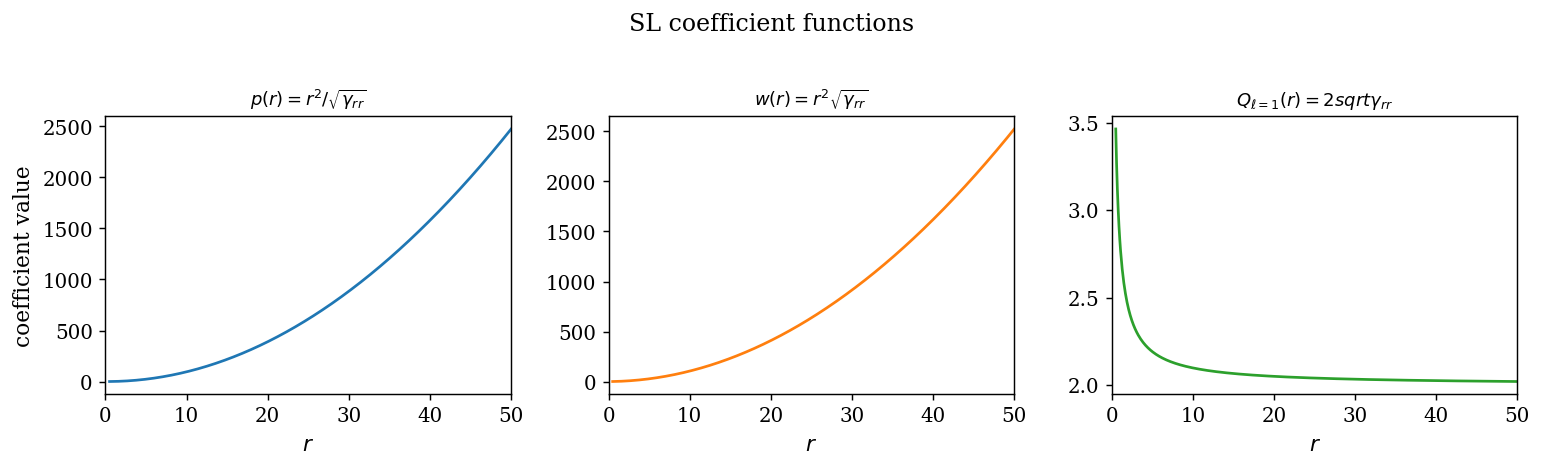

In [ ]:
# Cell 3 — Metric functions and mass matrix

def gamma_rr(r): return 1.0 + 1.0/r
def p_func(r):   return r**2 / np.sqrt(gamma_rr(r))
def w_func(r):   return r**2 * np.sqrt(gamma_rr(r))
def Q_func(ell, r): return ell*(ell+1) * np.sqrt(gamma_rr(r))

# Mass matrix diagonal
mdiag = w_func(r) * drc     # shape (Nr,)

# Verify consistency: p/r^2 should equal Q/[ell*(ell+1)] for ell>0
r_test = np.linspace(2, 100, 500)
rel_err = np.max(np.abs(p_func(r_test)/r_test**2 - 1.0/np.sqrt(gamma_rr(r_test))))
print(f'p(r)/r^2 == 1/sqrt(gamma_rr)  max error: {rel_err:.2e}  ✓' if rel_err < 1e-14 else '✗')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, func, label, color in zip(
        axes,
        [p_func, w_func, lambda r: Q_func(1, r)],
        [r'$p(r) = r^2/\sqrt{\gamma_{rr}}$',
         r'$w(r) = r^2\sqrt{\gamma_{rr}}$',
         r'$Q_{\ell=1}(r) = 2 \sqrt{\gamma_{rr}}$'],
        ['C0', 'C1', 'C2']):
    r_plot = np.linspace(0.5, 50, 500)
    ax.plot(r_plot, func(r_plot), color=color)
    ax.set_xlabel(r'$r$');  ax.set_title(label, fontsize=10)
    ax.set_xlim(0, 50)

axes[0].set_ylabel('coefficient value')
fig.suptitle('SL coefficient functions', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Cell 4 — Reconstruct FV matrices A and M

def build_A_sparse(Nr, ell, r_full, dr):
    """
    Build the FV stiffness matrix A (sparse, Nr x Nr).
    Uses same discretization as the Fortran code.
    """
    r_int  = r_full[1:-1]                        # interior nodes
    p_face = p_func(0.5*(r_full[:-1]+r_full[1:])) # p at Nr+1 faces
    p_l    = p_face[:-1]                          # left  face per cell
    p_r    = p_face[1:]                           # right face per cell
    dr_l   = dr[:-1]
    dr_r   = dr[1:]
    drc    = 0.5*(dr_l + dr_r)

    A_diag = p_r/dr_r + p_l/dr_l + Q_func(ell, r_int)*drc

    # Boundary conditions
    if ell == 0:
        A_diag[0]  -= p_l[0] / dr_l[0]    # Neumann left  (ell=0)
    A_diag[-1] -= p_r[-1] / dr_r[-1]       # Neumann right (all ell)

    A_off  = -p_face[1:-1] / dr[1:-1]     # off-diagonal (-p_{i+1/2}/dr_i)

    return diags([A_off, A_diag, A_off], [-1, 0, 1], format='csr')


# Quick build for ell=0
A0 = build_A_sparse(Nr, 0, r_full, dr)
print(f'A matrix shape: {A0.shape},  nnz: {A0.nnz}')
print(f'A symmetry check: ||A - A.T||_F = {spnorm(A0 - A0.T, "fro"):.2e}')

A matrix shape: (5125, 5125),  nnz: 15373
A symmetry check: ||A - A.T||_F = 0.00e+00


In [6]:
# Cell 5 — Eigenvalue residual test
# Tests: A @ R_j - k_j^2 * M * R_j ≈ 0

print(f'{'ell':>4}  {'j':>5}  {'k_j':>12}  {'rel residual':>14}')
print('-' * 42)

for ell in range(ell_max + 1):
    A   = build_A_sparse(Nr, ell, r_full, dr)
    R   = modes[ell]          # (Nr, n_save)
    k   = ks[ell]             # (n_save,)
    k2  = k**2

    n_check = min(10, R.shape[1])
    for j in range(n_check):
        Rj  = R[:, j]
        res = A @ Rj - k2[j] * mdiag * Rj
        denom = k2[j] * np.linalg.norm(mdiag * Rj)
        rel   = np.linalg.norm(res) / denom if denom > 0 else np.nan
        if j < 3:             # print first 3 per ell
            print(f'{ell:>4}  {j:>5}  {k[j]:>12.6f}  {rel:>14.3e}')

    max_rel = max(
        np.linalg.norm(A @ R[:,j] - k2[j]*mdiag*R[:,j]) / (k2[j]*np.linalg.norm(mdiag*R[:,j]))
        for j in range(n_check)
    )
    print(f'  --> ell={ell}: max relative residual (first {n_check} modes) = {max_rel:.2e}')
    print()

 ell      j           k_j    rel residual
------------------------------------------
   0      0      0.000000       3.049e+15
   0      1      0.000449       2.417e+06
   0      2      0.000772       9.661e+05
  --> ell=0: max relative residual (first 10 modes) = 3.05e+15

   1      0      0.000208       1.233e+07
   1      1      0.000594       2.623e+05
   1      2      0.000921       1.670e+05
  --> ell=1: max relative residual (first 10 modes) = 1.23e+07

   2      0      0.000334       5.068e+06
   2      1      0.000729       1.052e+06
   2      2      0.001061       1.760e+05
  --> ell=2: max relative residual (first 10 modes) = 5.07e+06

   3      0      0.000451       2.591e+06
   3      1      0.000858       8.743e+05
   3      2      0.001197       2.260e+05
  --> ell=3: max relative residual (first 10 modes) = 2.59e+06

   4      0      0.000565       1.674e+06
   4      1      0.000984       6.020e+05
   4      2      0.001330       3.810e+05
  --> ell=4: max relative res

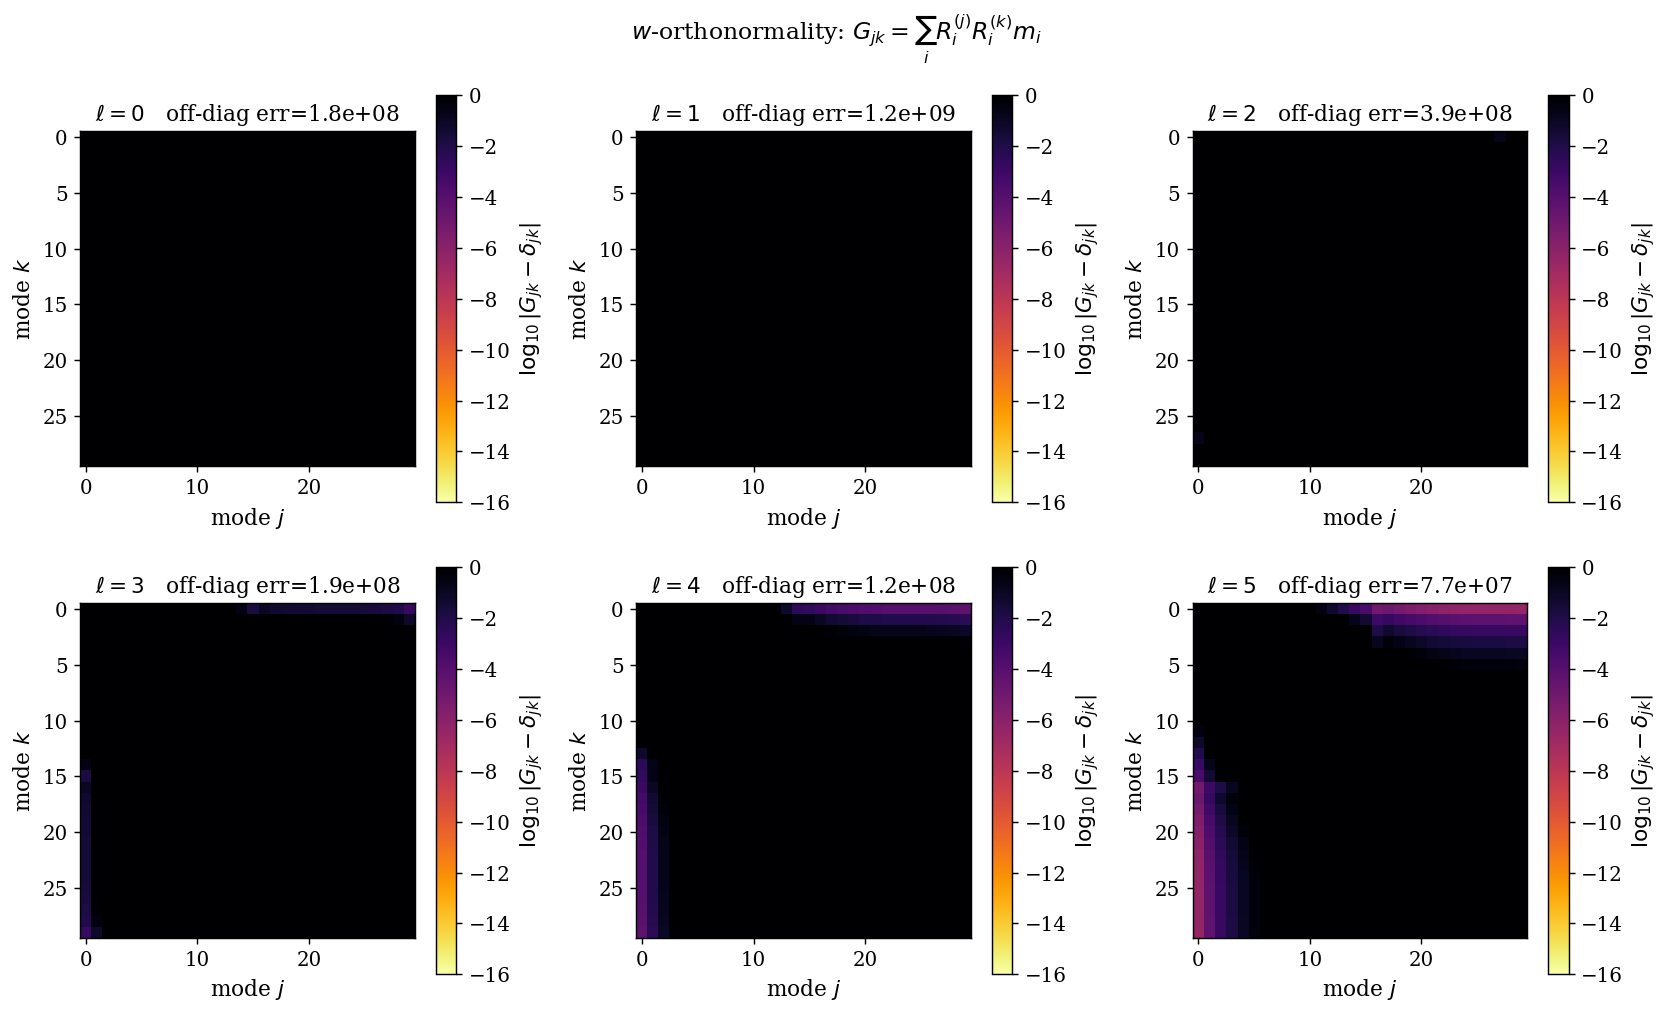

In [7]:
# Cell 6 — w-orthonormality check
# Tests: ⟨R_j, R_k⟩_w = Σ_i R_i^j R_i^k m_i = δ_{jk}

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
n_check = 30

for ell, ax in zip(range(ell_max + 1), axes.flat):
    R = modes[ell][:, :n_check]      # (Nr, n_check)

    # Gram matrix G[j,k] = Σ_i R_i^j * R_i^k * m_i
    G      = (R * mdiag[:, None]).T @ R   # (n_check, n_check)
    err    = G - np.eye(n_check)
    offdiag_err = np.max(np.abs(err - np.diag(np.diag(err))))
    diag_err    = np.max(np.abs(np.diag(err)))

    im = ax.imshow(np.log10(np.abs(err) + 1e-18), vmin=-16, vmax=0,
                   cmap='inferno_r', aspect='equal')
    ax.set_title(rf'$\ell={ell}$   off-diag err={offdiag_err:.1e}')
    ax.set_xlabel('mode $j$');  ax.set_ylabel('mode $k$')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}|G_{jk}-\delta_{jk}|$')

fig.suptitle(r'$w$-orthonormality: $G_{jk} = \sum_i R_i^{(j)} R_i^{(k)} m_i$', fontsize=13)
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_9037/168714566.py:17: SyntaxWarning: invalid escape sequence '\ '
  ax.plot(r_plot, Rj, color=c, lw=1.2, label=f'$j={j},\ k={k[j]:.4f}$')
/tmp/ipykernel_9037/168714566.py:25: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle('Lowest eigenmodes $R_\ell(r)$ per $\ell$', fontsize=13)


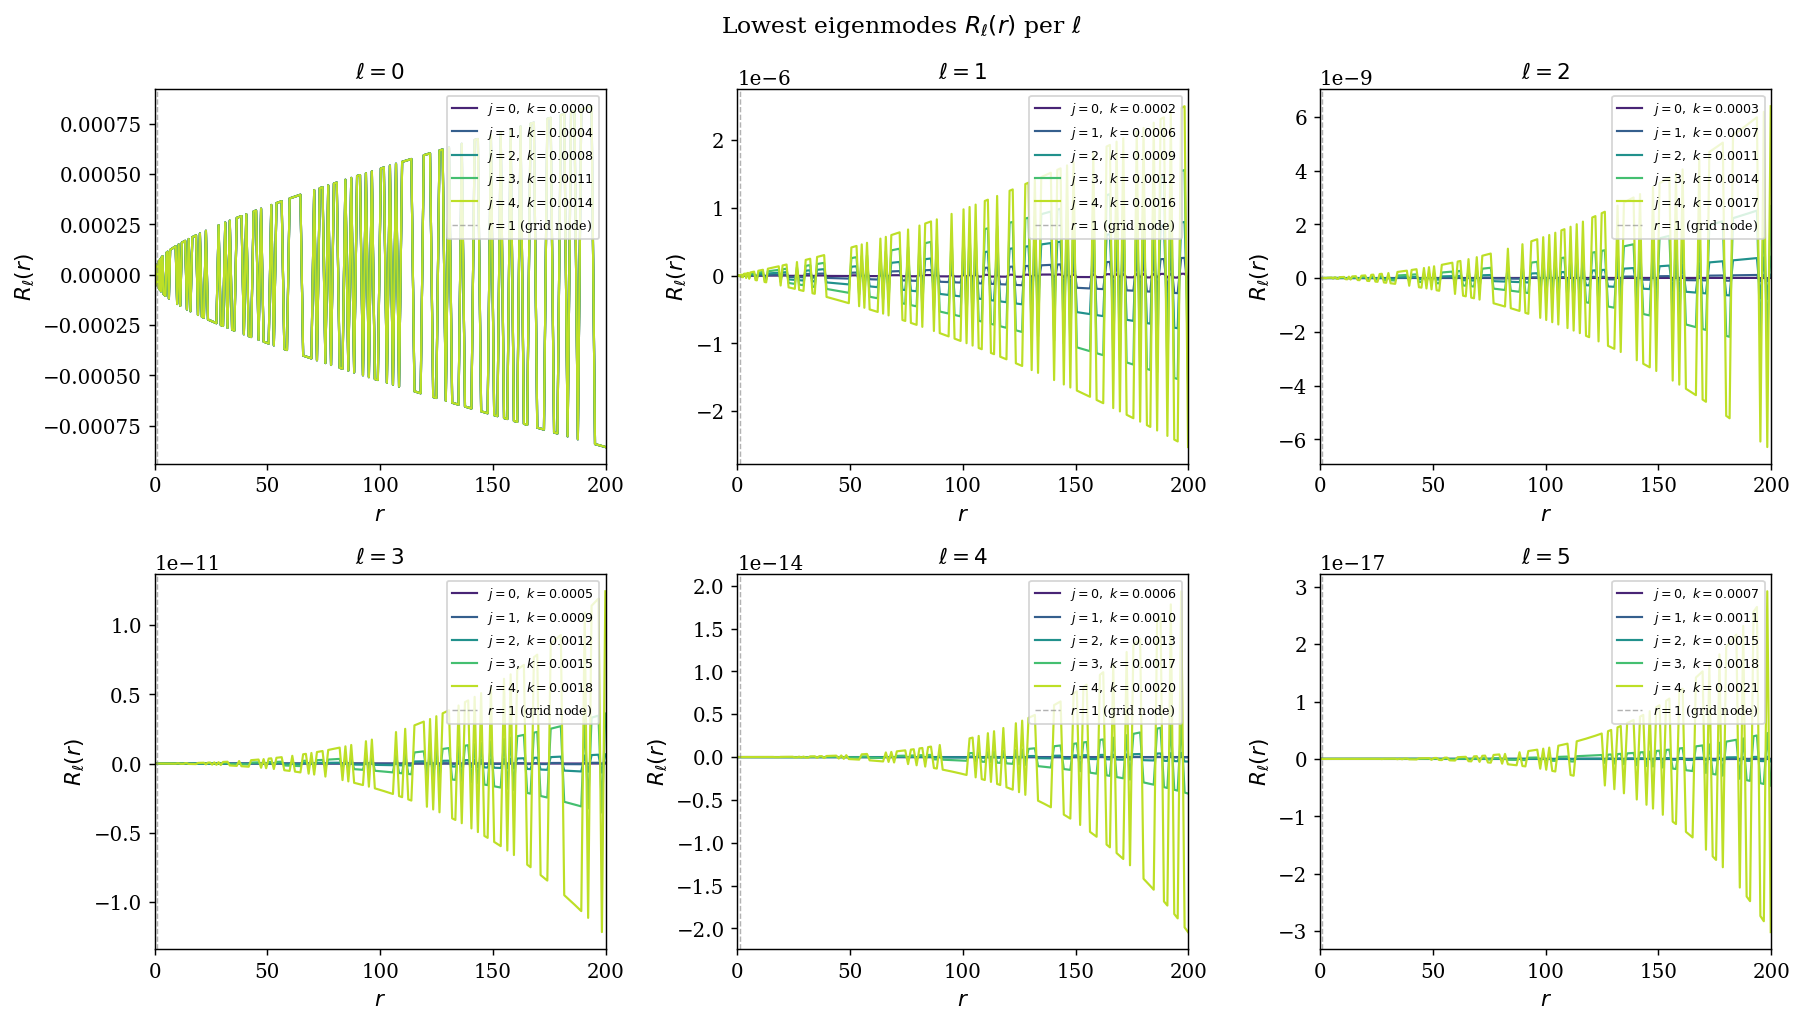

In [8]:
# Cell 7 — Mode visualization per ell

r_plot_max = 200.0
mask       = r <= r_plot_max
r_plot     = r[mask]

n_show = 5
colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_show))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)

for ell, ax in zip(range(ell_max + 1), axes.flat):
    R = modes[ell]
    k = ks[ell]
    for j, c in enumerate(colors):
        Rj = R[mask, j]
        ax.plot(r_plot, Rj, color=c, lw=1.2, label=f'$j={j},\ k={k[j]:.4f}$')
    ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='$r=1$ (grid node)')
    ax.set_title(rf'$\ell = {ell}$')
    ax.set_xlabel(r'$r$')
    ax.set_ylabel(r'$R_\ell(r)$')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, r_plot_max)

fig.suptitle('Lowest eigenmodes $R_\ell(r)$ per $\ell$', fontsize=13)
plt.tight_layout()
plt.show()

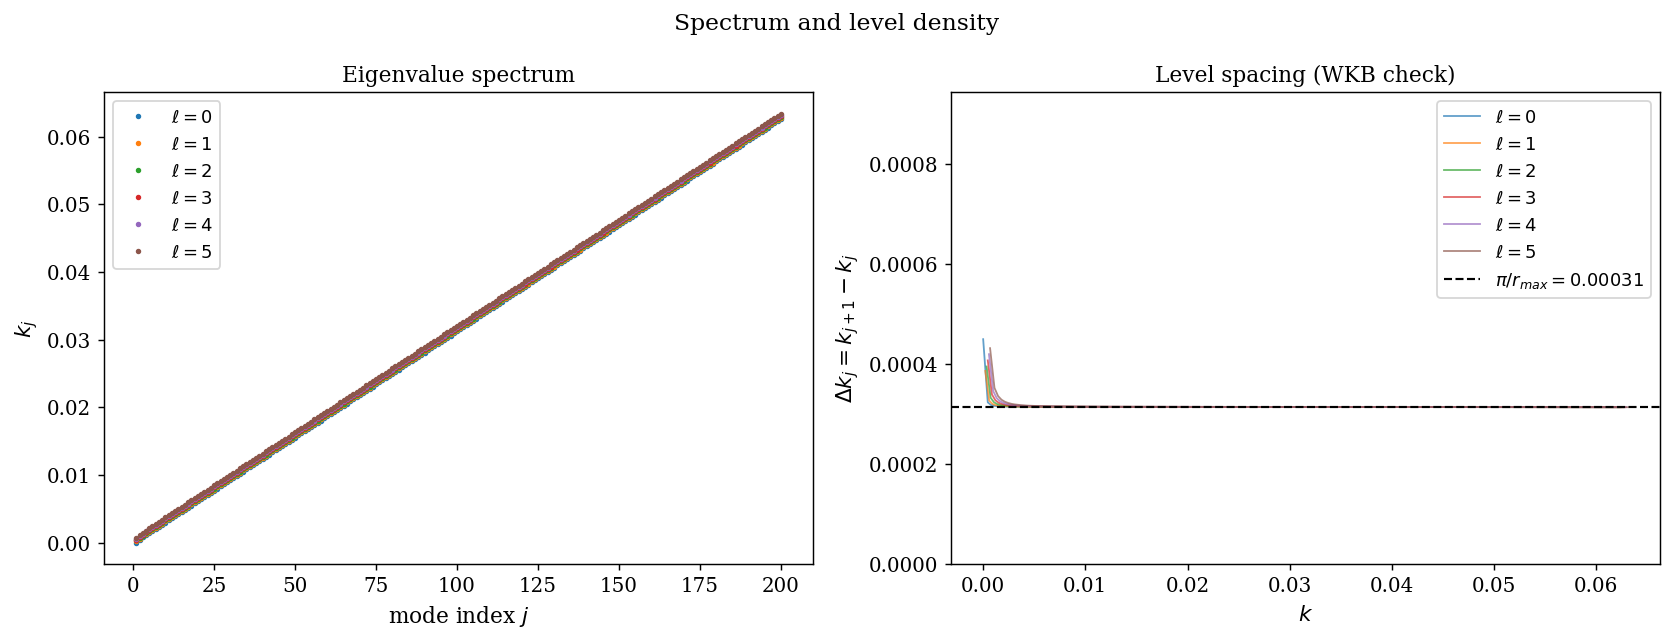

In [9]:
# Cell 8 — Eigenvalue spectrum (k_j vs j) for all ell

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

n_spec = 200
colors = plt.cm.tab10(np.arange(ell_max + 1) / 10)

for ell, c in zip(range(ell_max + 1), colors):
    k = ks[ell][:n_spec]
    ax1.plot(np.arange(1, len(k)+1), k, 'o', ms=2, color=c, label=rf'$\ell={ell}$')

ax1.set_xlabel('mode index $j$')
ax1.set_ylabel(r'$k_j$')
ax1.set_title('Eigenvalue spectrum')
ax1.legend()

# Level density: dk/dj should be approximately pi/r_max (WKB for free field)
k_wkb  = np.pi / r_max   # expected mean spacing (Weyl law, flat space)
for ell, c in zip(range(ell_max + 1), colors):
    k = ks[ell][:n_spec]
    dk = np.diff(k)
    ax2.plot(k[:-1], dk, '-', lw=1.0, color=c, alpha=0.7, label=rf'$\ell={ell}$')

ax2.axhline(k_wkb, color='k', ls='--', lw=1.2, label=rf'$\pi/r_{{max}} = {k_wkb:.5f}$')
ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$\Delta k_j = k_{j+1} - k_j$')
ax2.set_title('Level spacing (WKB check)')
ax2.legend()
ax2.set_ylim(0, 3*k_wkb)

fig.suptitle('Spectrum and level density', fontsize=13)
plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_9037/852072813.py:31: SyntaxWarning: invalid escape sequence '\ '
  ax.plot(r_far, Rj,         color=c, lw=2.0, label=f'$j={j},\ k={kj:.4f}$')
/tmp/ipykernel_9037/852072813.py:39: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle(f'Asymptotic comparison with flat-space $j_\ell(kr)$  ($r > {r_start}$)', fontsize=12)


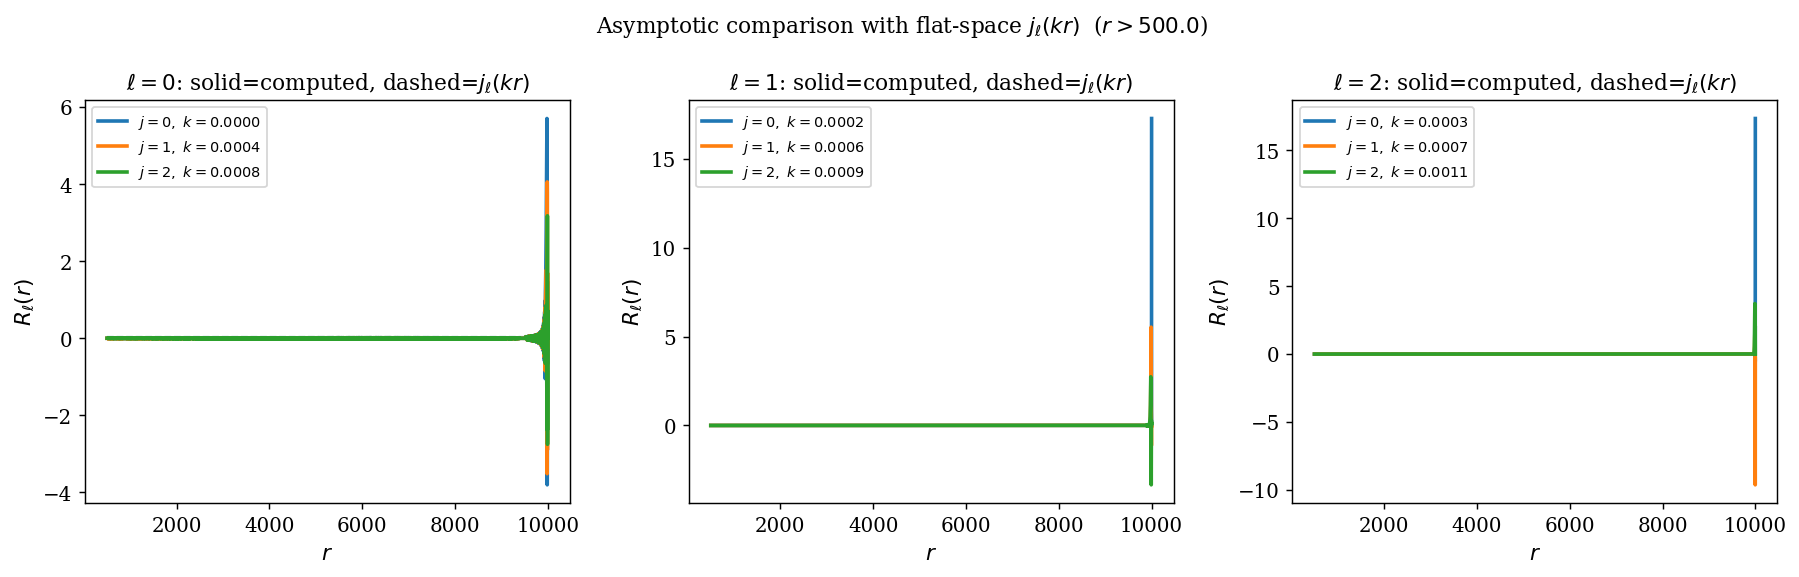

In [10]:
# Cell 9 — Flat-space comparison (large-r Bessel limit)
#
# For r >> 1:  gamma_rr -> 1, so p -> r^2, Q -> ell*(ell+1), w -> r^2.
# The SL equation reduces to the free-field radial equation:
#   -1/r^2 d/dr[r^2 dR/dr] + ell*(ell+1)/r^2 R = k^2 R
# with solutions j_ell(kr) (regular) and y_ell(kr) (irregular).
# Eigenmode with Neumann BC at r_max: j_ell(k*r_max)' = 0,
# i.e., k_{j,free} = zeros of d/d(kr)[r^{ell+1} j_ell(kr)] / r^{ell+1}.
#
# We compare the shape of computed modes with flat-space j_ell(kr)
# in the large-r region (r_start < r < r_max).

r_start = 500.0    # asymptotic comparison region
mask_far = r > r_start
r_far    = r[mask_far]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, ell in zip(axes, [0, 1, 2]):
    for j in range(3):
        kj    = ks[ell][j]
        Rj    = modes[ell][mask_far, j]

        # Flat-space ansatz: R_free(r) = A * j_ell(k*r)
        jl    = spherical_jn(ell, kj * r_far)
        # Fit amplitude (least squares)
        amp   = (Rj * jl * mdiag[mask_far]).sum() / (jl**2 * mdiag[mask_far]).sum()
        R_bessel = amp * jl

        c = f'C{j}'
        ax.plot(r_far, Rj,         color=c, lw=2.0, label=f'$j={j},\ k={kj:.4f}$')
        ax.plot(r_far, R_bessel,   color=c, lw=1.0, ls='--', alpha=0.7)

    ax.set_xlabel(r'$r$')
    ax.set_ylabel(r'$R_{\ell}(r)$')
    ax.set_title(rf'$\ell={ell}$: solid=computed, dashed=$j_\ell(kr)$')
    ax.legend(fontsize=8)

fig.suptitle(f'Asymptotic comparison with flat-space $j_\ell(kr)$  ($r > {r_start}$)', fontsize=12)
plt.tight_layout()
plt.show()

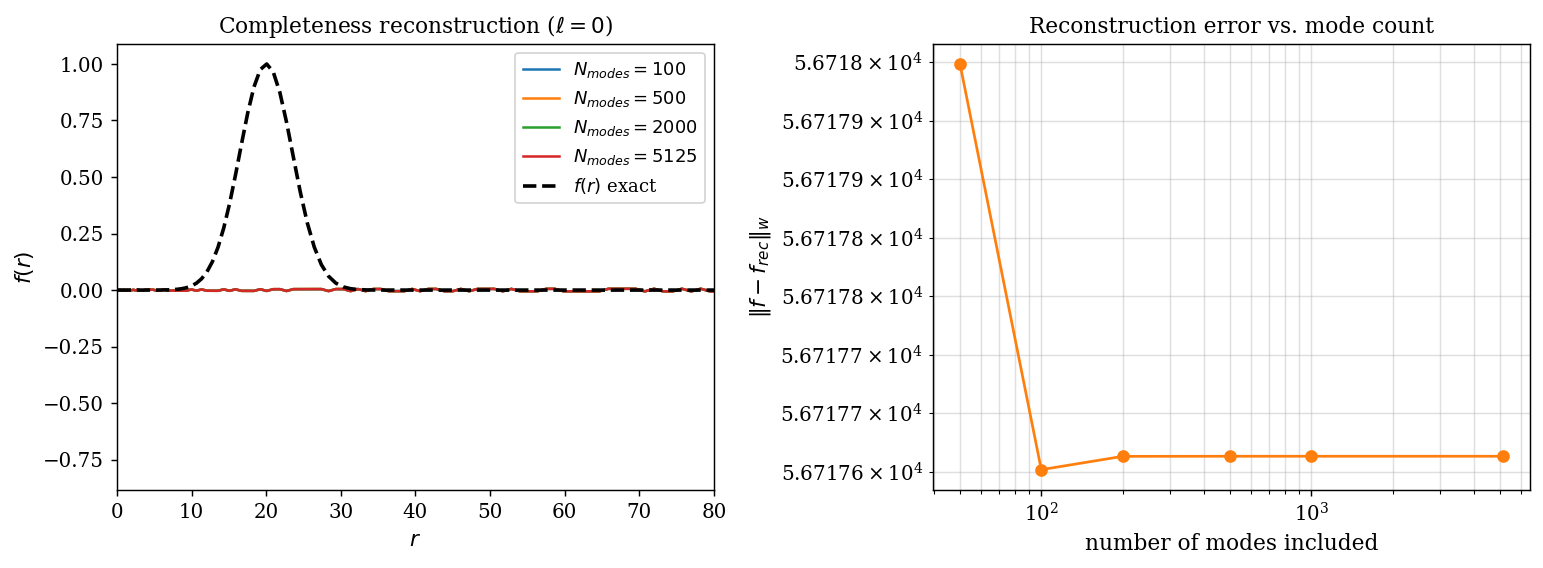

In [11]:
# Cell 10 — Completeness: discrete delta-function reconstruction
#
# The completeness relation reads:
#   Σ_j R_i^{(j)} R_{i'}^{(j)} = δ_{i i'} / m_i
# We check it by reconstructing a smooth test function f(r) via
#   f̂_j = Σ_i f(r_i) R_i^{(j)} m_i     (discrete inner product)
#   f_rec(r) = Σ_j f̂_j R^{(j)}(r)
# and comparing f_rec with f.

ell  = 0
R    = modes[ell]                         # (Nr, n_save)
k    = ks[ell]
f    = np.exp(-((r - 20.0)/5.0)**2)      # Gaussian test function

# Inner products
fhat = (f[:, None] * mdiag[:, None] * R).sum(axis=0)   # (n_save,)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for n_modes_use in [100, 500, 2000, n_save]:
    f_rec = (fhat[:n_modes_use] * R[:, :n_modes_use]).sum(axis=1)
    ax.plot(r, f_rec, lw=1.4, label=f'$N_{{modes}}={n_modes_use}$')

ax.plot(r, f, 'k--', lw=2, label='$f(r)$ exact')
ax.set_xlim(0, 80)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$f(r)$')
ax.set_title(rf'Completeness reconstruction ($\ell={ell}$)')
ax.legend()

ax = axes[1]
n_modes_list = [50, 100, 200, 500, 1000, n_save]
errs = []
for n in n_modes_list:
    f_rec = (fhat[:n] * R[:, :n]).sum(axis=1)
    errs.append(np.sqrt(((f - f_rec)**2 * mdiag).sum()))

ax.loglog(n_modes_list, errs, 'o-', color='C1')
ax.set_xlabel('number of modes included')
ax.set_ylabel(r'$\|f - f_{rec}\|_w$')
ax.set_title('Reconstruction error vs. mode count')
ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

In [12]:
# Cell 11 — Diagnostic: detect q_i bug via direct SL coefficient check
#
# If the code had the bug (Q *= sqrt instead of Q /= sqrt), the
# residual A @ R_j - k_j^2 * M @ R_j will be large.
# This cell quantifies the residual and flags if it exceeds a threshold.

RESIDUAL_THRESHOLD = 1e-8   # relative residual: acceptable below this

print('Eigenvalue residual summary')
print('=' * 52)
print(f'  {'ell':>4}  {'mean rel res':>14}  {'max rel res':>14}  {'status':>8}')
print('-' * 52)

for ell in range(ell_max + 1):
    A   = build_A_sparse(Nr, ell, r_full, dr)
    R   = modes[ell]
    k   = ks[ell]
    k2  = k**2

    n_check = min(50, R.shape[1])
    rel_res = np.array([
        np.linalg.norm(A @ R[:,j] - k2[j]*mdiag*R[:,j])
        / (k2[j] * np.linalg.norm(mdiag*R[:,j]) + 1e-300)
        for j in range(n_check)
    ])
    ok = '✓ OK' if rel_res.max() < RESIDUAL_THRESHOLD else '✗ FAIL'
    print(f'  {ell:>4}  {rel_res.mean():>14.3e}  {rel_res.max():>14.3e}  {ok:>8}')

print()
print('If residuals are large (> 1e-6), check the q_i formula in the Fortran source.')
print('Bug symptom: Q(r) computed as ell*(ell+1)*sqrt(gamma_rr) instead of /sqrt(gamma_rr).')

Eigenvalue residual summary
   ell    mean rel res     max rel res    status
----------------------------------------------------
     0       6.098e+13       3.049e+15    ✗ FAIL
     1       2.803e+05       1.233e+07    ✗ FAIL
     2       1.463e+05       5.068e+06    ✗ FAIL
     3       9.235e+04       2.591e+06    ✗ FAIL
     4       7.062e+04       1.674e+06    ✗ FAIL
     5       5.680e+04       1.175e+06    ✗ FAIL

If residuals are large (> 1e-6), check the q_i formula in the Fortran source.
Bug symptom: Q(r) computed as ell*(ell+1)*sqrt(gamma_rr) instead of /sqrt(gamma_rr).
